# MNIST Binder Demo

This notebook trains a compact CNN on a subset of MNIST so it runs comfortably on Binder CPU sessions. It then compares three `pytorch-ood` detectors on MNIST vs. FashionMNIST:

- `MaxSoftmax`
- `EnergyBased`
- `Mahalanobis`


In [1]:
import random

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import ConcatDataset, DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import MNIST, FashionMNIST

from pytorch_ood.detector import EnergyBased, Mahalanobis, MaxSoftmax
from pytorch_ood.utils import OODMetrics, ToUnknown

torch.manual_seed(0)
random.seed(0)

device = torch.device("cpu")
batch_size = 128
epochs = 5
train_size = 12000
fit_size = 4000
test_size = 4000

transform = transforms.Compose(
    [
        transforms.ToTensor(),
    ]
)

In [2]:
train_dataset_full = MNIST("data", train=True, download=True, transform=transform)
test_in_dataset_full = MNIST("data", train=False, download=True, transform=transform)
test_out_dataset_full = FashionMNIST(
    "data", train=False, download=True, transform=transform, target_transform=ToUnknown()
)

train_indices = torch.randperm(len(train_dataset_full))[:train_size]
fit_indices = train_indices[:fit_size]
test_in_indices = torch.randperm(len(test_in_dataset_full))[:test_size]
test_out_indices = torch.randperm(len(test_out_dataset_full))[:test_size]

train_dataset = Subset(train_dataset_full, train_indices.tolist())
train_fit_dataset = Subset(train_dataset_full, fit_indices.tolist())
test_in_dataset = Subset(test_in_dataset_full, test_in_indices.tolist())
test_out_dataset = Subset(test_out_dataset_full, test_out_indices.tolist())

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
train_eval_loader = DataLoader(
    train_fit_dataset, batch_size=batch_size, shuffle=False, num_workers=0
)
test_in_loader = DataLoader(test_in_dataset, batch_size=batch_size, num_workers=0)
ood_loader = DataLoader(
    ConcatDataset([test_in_dataset, test_out_dataset]), batch_size=batch_size, num_workers=0
)

len(train_dataset), len(train_fit_dataset), len(test_in_dataset), len(test_out_dataset)

(12000, 4000, 4000, 4000)

In [3]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward_feature_maps(self, x):
        return self.features(x)

    def forward_features(self, x):
        z = self.forward_feature_maps(x)
        z = self.pool(z)
        return torch.flatten(z, 1)

    def forward(self, x):
        z = self.forward_features(x)
        return self.classifier(z)


model = SmallCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

model.train()
for epoch in range(epochs):
    running_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)

    print(f"epoch={epoch + 1} loss={running_loss / len(train_dataset):.4f}")

epoch=1 loss=2.2597
epoch=2 loss=1.9269
epoch=3 loss=1.7065
epoch=4 loss=1.5619
epoch=5 loss=1.4984


In [4]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x, y in test_in_loader:
        logits = model(x.to(device))
        pred = logits.argmax(dim=1).cpu()
        correct += (pred == y).sum().item()
        total += y.numel()

accuracy = correct / total
print(f"MNIST accuracy on the evaluation subset: {accuracy:.3f}")

MNIST accuracy on the evaluation subset: 0.434


In [5]:
detectors = {
    "MaxSoftmax": MaxSoftmax(model),
    "EnergyBased": EnergyBased(model),
    "Mahalanobis": Mahalanobis(model.forward_features, eps=0.0),
}
detectors["Mahalanobis"].fit(train_eval_loader)

detector_results = {}
detector_scores = {}

for name, detector in detectors.items():
    metrics = OODMetrics()
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for x, y in ood_loader:
            scores = detector(x.to(device)).cpu()
            metrics.update(scores, y)
            all_scores.append(scores)
            all_labels.append(y)

    detector_results[name] = metrics.compute()
    detector_scores[name] = (torch.cat(all_scores), torch.cat(all_labels))

for name, metrics in sorted(
    detector_results.items(), key=lambda item: item[1]["AUROC"], reverse=True
):
    print(
        f"{name:12s} AUROC={metrics['AUROC']:.3f}  AUPR-OUT={metrics['AUPR-OUT']:.3f}  FPR95TPR={metrics['FPR95TPR']:.3f}"
    )

Mahalanobis  AUROC=0.999  AUPR-OUT=0.999  FPR95TPR=0.000
EnergyBased  AUROC=0.289  AUPR-OUT=0.369  FPR95TPR=0.941
MaxSoftmax   AUROC=0.253  AUPR-OUT=0.363  FPR95TPR=0.979


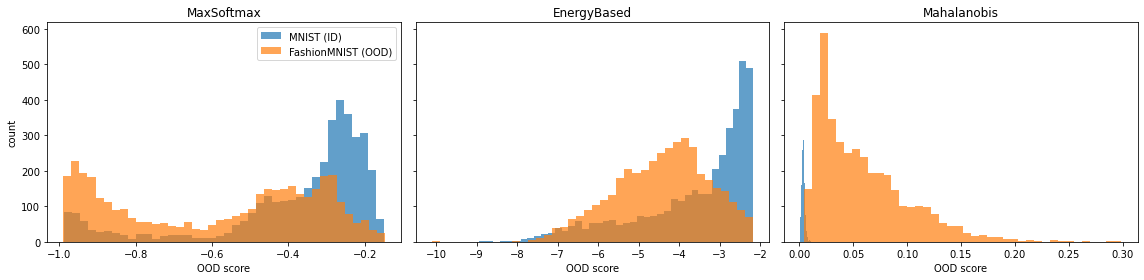

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, name in zip(axes, ["MaxSoftmax", "EnergyBased", "Mahalanobis"]):
    scores, labels = detector_scores[name]
    in_scores = scores[labels >= 0]
    out_scores = scores[labels < 0]

    ax.hist(in_scores.numpy(), bins=40, alpha=0.7, label="MNIST (ID)")
    ax.hist(out_scores.numpy(), bins=40, alpha=0.7, label="FashionMNIST (OOD)")
    ax.set_title(name)
    ax.set_xlabel("OOD score")

axes[0].set_ylabel("count")
axes[0].legend()
plt.tight_layout()
plt.show()